# USA Real Estate Data Analysis

## Project preview
This dataset contains Real Estate listings in the US broken by State and zip code.

### Data Source:

> https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset/data

### Content:

The dataset has 1 CSV file with 12 columns -

1. `realtor-data.csv` (2,226,382 entries)
    - `brokered by` - categorically encoded agency/broker
    - `status` - Housing status - a. ready for sale or b. ready to build
    - `price`- Housing price, it is either the current listing price or recently sold price if the house is sold recently
    - `bed` - # of beds
    - `bath` - # of bathrooms
    - `acre_lot` - Property / Land size in acres
    - `street` - categorically encoded street address
    - `city` - city name
    - `state` - state name
    - `zip_code` - postal code of the area
    - `house_size`- house area/size/living space in square feet
    - `prev_sold_date` - Previously sold date

**Note:**
1. `brokered by` and `street` addresses were categorically encoded due to data privacy policy
2. `acre_lot` means the total land area, and `house_size` denotes the living space/building area

### Goals
1. What is the overall picture of USA housing prices w.r.t. locations?
2. How are housing prices correlated with location attributes?
3. Do house attributes (bedroom, bathroom count) strongly correlate
   with the price? Are there any hidden patterns?

**Author:** Timerbulat Khalilov

**Date:** April 2026

## Data preview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
df = pd.read_csv('data/realtor-data.zip.csv')
df.sample(5)

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
735766,"105,223.00",for_sale,"15,900.00",NaN,NaN,0.80,"481,702.00",Monon,Indiana,"47,959.00",NaN,NaN
1114881,"4,231.00",for_sale,"555,825.00",NaN,NaN,1.16,"1,905,950.00",Palmview,Texas,"78,573.00",NaN,NaN
1317735,"33,728.00",for_sale,"584,990.00",3.00,1.00,2.51,"754,993.00",Palmdale,California,"93,551.00","1,680.00",2001-12-04
116289,"12,994.00",for_sale,"635,000.00",1.00,1.00,NaN,"795,357.00",New York City,New York,"11,103.00",633.00,NaN
2179080,"78,539.00",sold,"749,951.00",3.00,2.00,0.57,"588,040.00",Oregon City,Oregon,"97,045.00","2,200.00",2022-02-22


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          str    
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            str    
 8   state           str    
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  str    
dtypes: float64(8), str(4)
memory usage: 203.8 MB


### Observation:
- Dataset has 2,226,382 rows and 12 columns
- `bed`, `bath`, and `zip_code` are `float64` - should be converted to `int`
- `prev_sold_date` is `str` = should be converted to `datetime`
- missing values need to be checked

## Data Preprocessing

Changing the data types where it apropriate:

In [4]:
df[['bed', 'bath', 'zip_code']] = df[['bed', 'bath', 'zip_code']].astype('Int64')
df['prev_sold_date'] = pd.to_datetime(df['prev_sold_date'], format='%Y-%m-%d')

Lets observe missing values by columns.

In [5]:
df.isna().sum()

brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64

<Axes: >

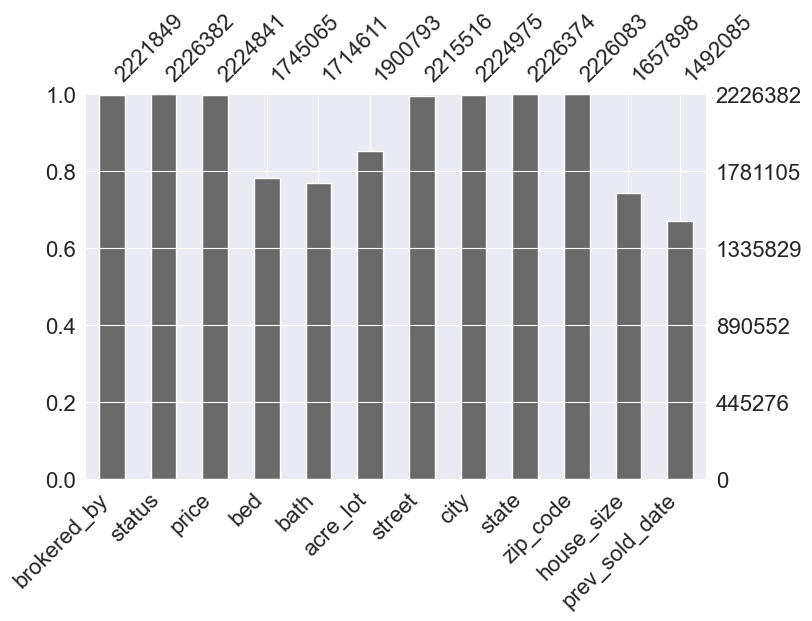

In [6]:
msno.bar(df, figsize=(8, 5))

Let's display the correlation of missing values by columns using matrix and heatmap.

/Users/Timerbulat/programming/real_estate_project/.venv/lib/python3.12/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


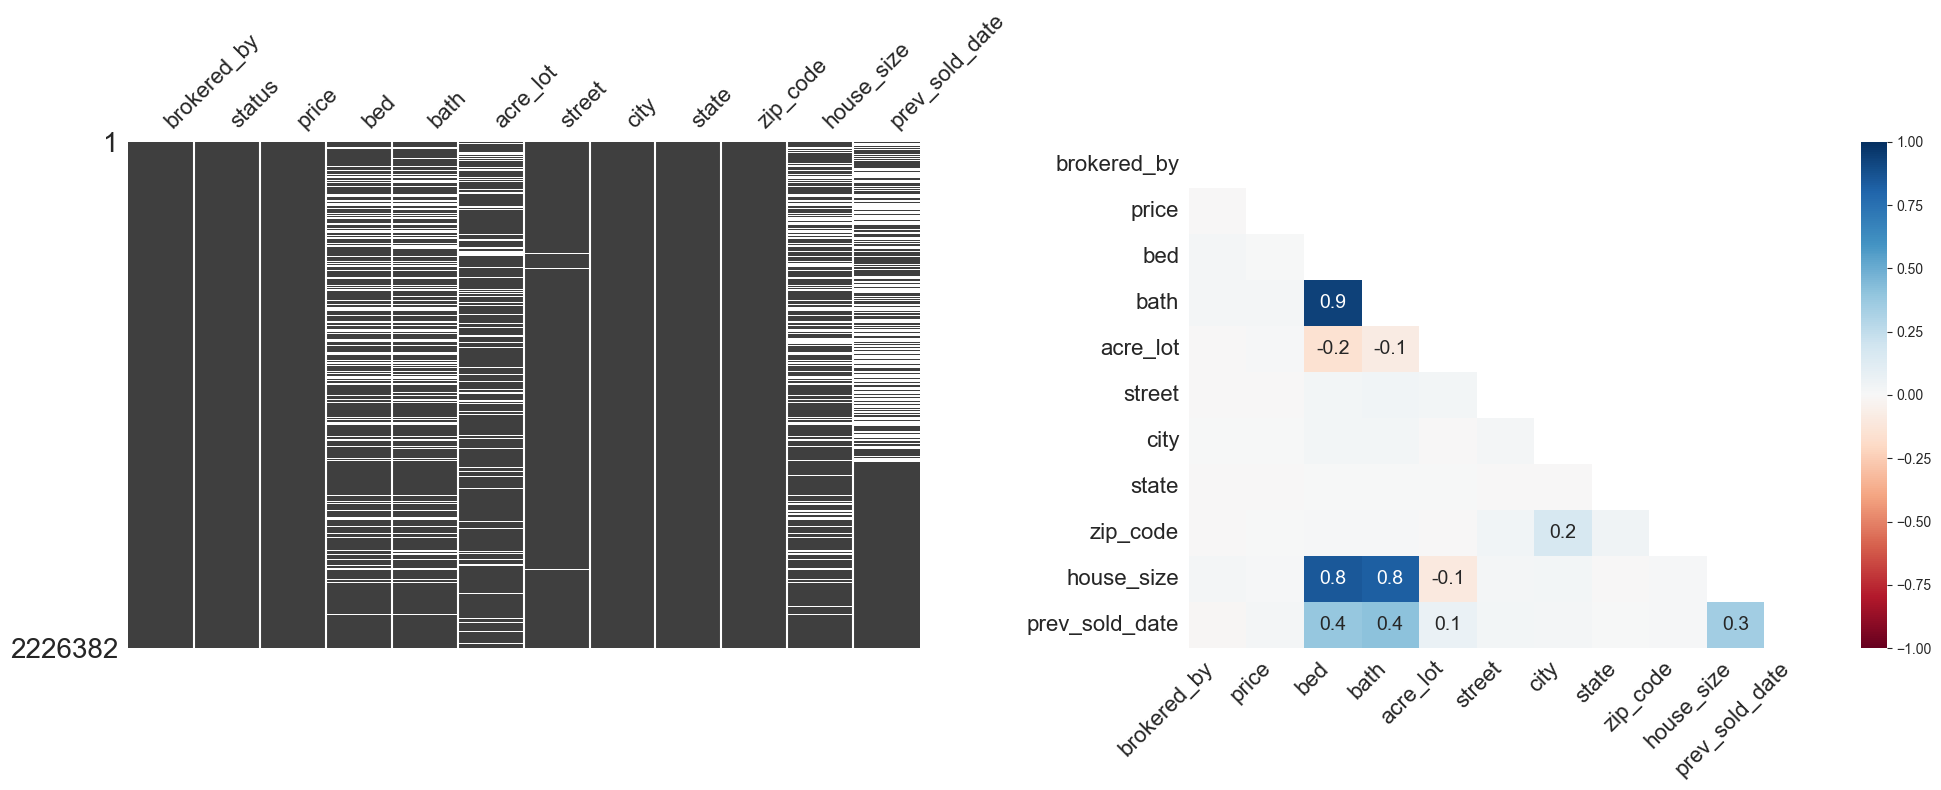

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

msno.matrix(df, ax=axes[0])
msno.heatmap(df, ax=axes[1])

plt.tight_layout()
plt.show()

*Note:* We can notice that there is strong correlatioin in missing values between:
- `bad` and `bath` : 0.9
- `bed`, `bath` and `house_size` : 0.8

The correlation between `house_size` and `acre_lot` is very low. We can assume that missing values in `acre_lot` could be equal to the `house_size`.

We will drop the listings without `price` data.

We have three correlated missing values: `bed`, `bath`, and `house_size`. We will fill this values with same `price` and `state` average

In [8]:
for column in ['price', 'state', 'zip_code']:
    df = df.dropna(subset=[column])

df = df.dropna(subset=['bed', 'bath', 'house_size'], how='all')

for column in ['bed', 'bath', 'house_size', 'acre_lot']:
    df[column] = df[column].fillna(df.groupby('state')[column].transform('median'))
    df[column] = df[column].round().astype('Int64')

df['city'] = df['city'].fillna(df.groupby('state')['city'].transform(lambda x: x.mode()[0]))

df[['brokered_by', 'street']] = df[['brokered_by', 'street']].fillna(0)

df = df.reset_index(drop=True)

df.isna().sum()

brokered_by            0
status                 0
price                  0
bed                    0
bath                   0
acre_lot               0
street                 0
city                   0
state                  0
zip_code               0
house_size             0
prev_sold_date    414965
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(112)

In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size,prev_sold_date
count,"1,766,142.00","1,766,142.00","1,766,142.00","1,766,142.00","1,766,142.00","1,766,142.00","1,766,142.00","1,766,142.00",1351244
mean,"52,790.89","580,886.01",3.27,2.48,10.80,"927,695.65","52,138.94","2,654.43",2017-10-27 06:52:17.269065
min,0.00,0.00,1.00,1.00,0.00,0.00,0.00,4.00,1901-01-01 00:00:00
25%,"24,186.00","234,900.00",3.00,2.00,0.00,"462,208.25","28,711.00","1,332.00",2017-01-12 00:00:00
50%,"52,850.00","375,000.00",3.00,2.00,0.00,"928,206.00","48,746.00","1,748.00",2021-12-03 00:00:00
75%,"79,068.00","599,900.00",4.00,3.00,0.00,"1,391,335.75","78,501.00","2,357.00",2022-03-04 00:00:00
max,"110,142.00","875,000,000.00",473.00,830.00,"100,000.00","2,001,321.00","99,999.00","1,040,400,400.00",3019-04-02 00:00:00
std,"30,518.49","1,480,536.92",1.56,1.63,735.75,"537,355.67","29,672.75","783,006.47",NaN


### Anomalies Detected in describe() Output

The statistics reveal several physically impossible values that would skew visualizations and analysis:

1. **Price**: Min $0, Max $875,000,000
   - $0 listings = invalid transactions (gifts, liens, errors)
   - $875M is unrealistic for typical real estate (>99th percentile outlier)

2. **Bedrooms**: Max 473 bedrooms
   - Impossible for residential property
   - Likely data entry error or aggregated commercial building

3. **Bathrooms**: Max 830 bathrooms
   - Absurd figure; even 473-bed property wouldn't have 830 baths
   - Data error

4. **House Size**: Max 1,040,400,400 sq ft
   - This is larger than Manhattan (23,000 sq miles = ~1B sq ft)
   - Clear decimal/entry error

5. **Date**: Min 1901, Max year 3019
   - 1901 data is >120 years old (outside typical real estate cycle)
   - Year 3019 is obviously a typo (1000 years in future)

These outliers must be filtered before proceeding with analysis.

In [12]:
df[['price', 'bed', 'bath', 'house_size', 'prev_sold_date']].describe()

,price,bed,bath,house_size,prev_sold_date
count,"1,766,142.00","1,766,142.00","1,766,142.00","1,766,142.00",1351244
mean,"580,886.01",3.27,2.48,"2,654.43",2017-10-27 06:52:17.269065
min,0.00,1.00,1.00,4.00,1901-01-01 00:00:00
25%,"234,900.00",3.00,2.00,"1,332.00",2017-01-12 00:00:00
50%,"375,000.00",3.00,2.00,"1,748.00",2021-12-03 00:00:00
75%,"599,900.00",4.00,3.00,"2,357.00",2022-03-04 00:00:00
max,"875,000,000.00",473.00,830.00,"1,040,400,400.00",3019-04-02 00:00:00
std,"1,480,536.92",1.56,1.63,"783,006.47",NaN


In [13]:
# Price: remove $0 and extreme outliers
df = df[df['price'] > 0]
df = df[df['price'] <= 10_000_000]

# Bedrooms: cap at 10 (realistic max for residential)
df = df[df['bed'] <= 10]

# Bathrooms: cap at 10
df = df[df['bath'] <= 10]

# House size: cap at 20,000 sq ft
df = df[df['house_size'] <= 20_000]

# Date: keep only plausible historical range
df = df[(df['prev_sold_date'].isna()) | 
        (df['prev_sold_date'].dt.year.between(1990, 2024))]

df = df.reset_index(drop=True)
print(f"Remaining records: {len(df):,}")

Remaining records: 1,738,475


### Cleaning Strategy

Based on the anomaly counts above, we'll apply targeted filters to remove clear data entry errors while preserving legitimate market diversity.

**Price filtering ($0 < price ≤ $10M):** Remove listings with $0 prices (invalid transactions, gifts, liens) and cap at $10M. Properties above $10M represent edge cases that skew the overall price scale and distort visualizations without adding statistical value for typical real estate analysis.

**Bedroom & Bathroom filtering (≤ 10 each):** Cap bedrooms and bathrooms at 10. No residential property realistically has 473 bedrooms or 830 bathrooms — these are clear data entry errors. A threshold of 10 captures legitimate luxury estates while removing impossible values.

**House size filtering (≤ 20,000 sq ft):** Cap at 20,000 square feet. This includes large mansions and estates. The maximum of 1 billion square feet is obviously a decimal point error (someone likely entered 1040400400 instead of 10404 or 104.04). This filter removes nonsensical values while keeping genuinely large properties.

**Date filtering (1990–2024):** Keep only transactions from 1990 onward. The dataset represents modern US real estate (mostly 2017-2021). Data from 1901 is beyond the typical analysis window, and year 3019 is clearly a typo. This filter ensures temporal consistency.

**Acre lot — NO filtering applied:** Unlike other fields, acre_lot shows legitimate market diversity: urban properties (75%) have 0 acres while rural properties range up to 100,000 acres. This bimodal distribution is a real feature of the market, not an error. We keep it to preserve urban vs. rural property distinction for location analysis.

In [14]:
df[['price', 'bed', 'bath', 'house_size', 'prev_sold_date']].describe()


,price,bed,bath,house_size,prev_sold_date
count,"1,738,475.00","1,738,475.00","1,738,475.00","1,738,475.00",1327244
mean,"538,578.93",3.23,2.45,"1,986.59",2018-05-03 07:08:59.211780
min,1.00,1.00,1.00,4.00,1990-01-01 00:00:00
25%,"234,800.00",3.00,2.00,"1,330.00",2017-06-23 00:00:00
50%,"374,900.00",3.00,2.00,"1,744.00",2021-12-07 00:00:00
75%,"599,000.00",4.00,3.00,"2,349.00",2022-03-07 00:00:00
max,"10,000,000.00",10.00,10.00,"20,000.00",2024-10-26 00:00:00
std,"670,523.20",1.09,1.08,"1,080.87",NaN


## Geographic Analysis: Average Prices by State

Now that the data is clean, let's explore the overall picture of USA housing prices across locations. We'll start by analyzing price patterns at the state level to understand regional variation and identify which states have the highest and lowest average property prices.

In [15]:
state_prices = df.groupby('state')['price'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(2).sort_values('mean', ascending=False)

print("Price Statistics by State (sorted by mean price):")
print(state_prices)

Price Statistics by State (sorted by mean price):
                       count         mean     median          std        min  \
state                                                                          
Hawaii                  5083 1,169,269.23 775,000.00 1,309,112.63  18,000.00   
Virgin Islands           301 1,143,039.19 595,000.00 1,403,888.87  92,000.00   
California            192744   959,112.08 699,000.00   922,548.29       1.00   
District of Columbia    6365   853,811.93 650,000.00   785,373.63   7,900.00   
Utah                   11196   847,349.55 589,000.00   903,004.36  12,000.00   
Montana                 6399   812,977.75 489,000.00 1,134,606.01      50.00   
New York               90181   804,476.98 449,990.00 1,147,724.91       1.00   
Colorado               24764   790,853.55 560,000.00   899,177.29   2,500.00   
Massachusetts          35073   710,761.65 524,900.00   754,376.48  10,000.00   
Wyoming                 1909   691,425.35 385,000.00 1,070,053.20  10,

/var/folders/wn/wr_2n7zd2td_cdx34ymqxpsc0000gp/T/ipykernel_25964/387017296.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top15, y='state', x='price', ax=axes[1], palette='Set2')


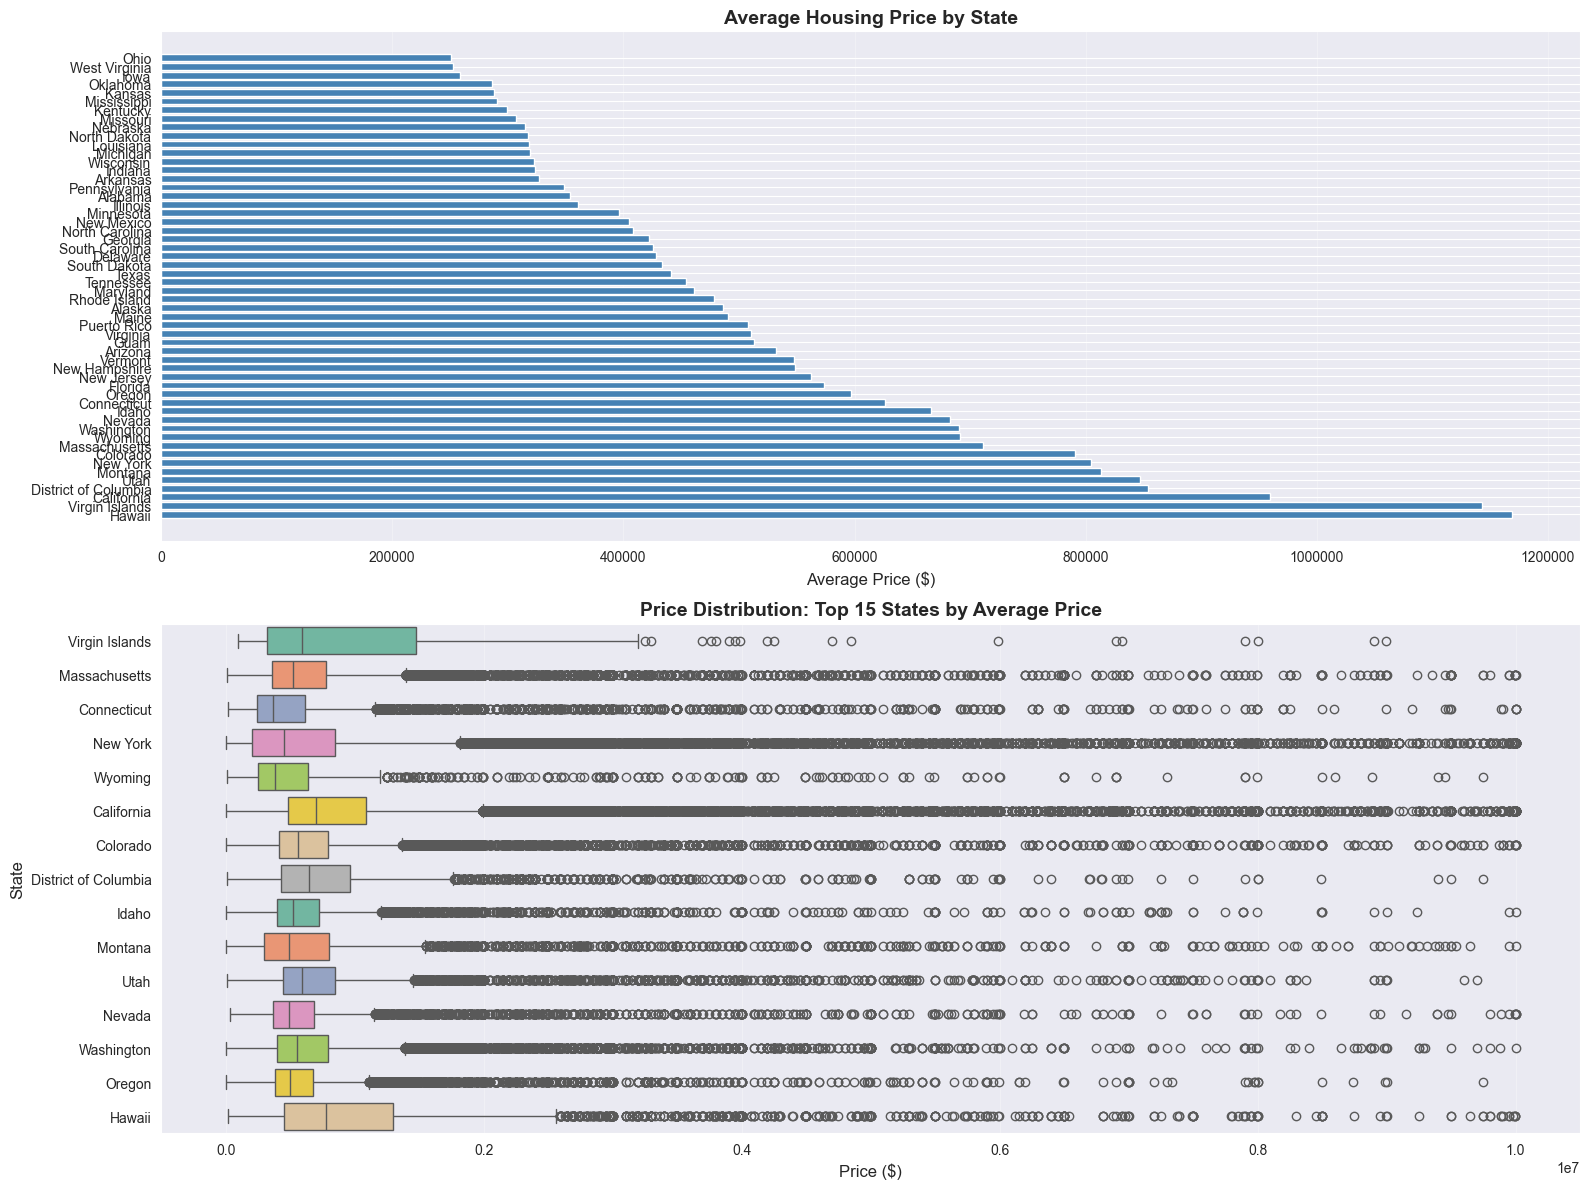

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Mean price by state (sorted)
state_mean = df.groupby('state')['price'].mean().sort_values(ascending=False)
axes[0].barh(state_mean.index, state_mean.values, color='steelblue')
axes[0].set_xlabel('Average Price ($)', fontsize=12)
axes[0].set_title('Average Housing Price by State', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].ticklabel_format(style='plain', axis='x')

# Plot 2: Box plot of price distribution by top 15 states
top_15_states = state_mean.head(15).index
df_top15 = df[df['state'].isin(top_15_states)]
sns.boxplot(data=df_top15, y='state', x='price', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Price ($)', fontsize=12)
axes[1].set_ylabel('State', fontsize=12)
axes[1].set_title('Price Distribution: Top 15 States by Average Price', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
national_mean = df['price'].mean()
national_median = df['price'].median()

print(f"National Average Price: ${national_mean:,.2f}")
print(f"National Median Price: ${national_median:,.2f}")
print(f"\n")

# Compare state means to national average
state_comparison = state_prices[['count', 'mean', 'median']].copy()
state_comparison['vs_national_mean'] = (state_comparison['mean'] - national_mean).round(2)
state_comparison['% difference'] = ((state_comparison['mean'] - national_mean) / national_mean * 100).round(2)

print("Top 10 Most Expensive States (vs National Average):")
print(state_comparison.head(10))

print("\n")
print("Top 10 Least Expensive States (vs National Average):")
print(state_comparison.tail(10))

National Average Price: $538,578.93
National Median Price: $374,900.00


Top 10 Most Expensive States (vs National Average):
                       count         mean     median  vs_national_mean  \
state                                                                    
Hawaii                  5083 1,169,269.23 775,000.00        630,690.30   
Virgin Islands           301 1,143,039.19 595,000.00        604,460.26   
California            192744   959,112.08 699,000.00        420,533.15   
District of Columbia    6365   853,811.93 650,000.00        315,233.00   
Utah                   11196   847,349.55 589,000.00        308,770.62   
Montana                 6399   812,977.75 489,000.00        274,398.82   
New York               90181   804,476.98 449,990.00        265,898.05   
Colorado               24764   790,853.55 560,000.00        252,274.62   
Massachusetts          35073   710,761.65 524,900.00        172,182.72   
Wyoming                 1909   691,425.35 385,000.00        1

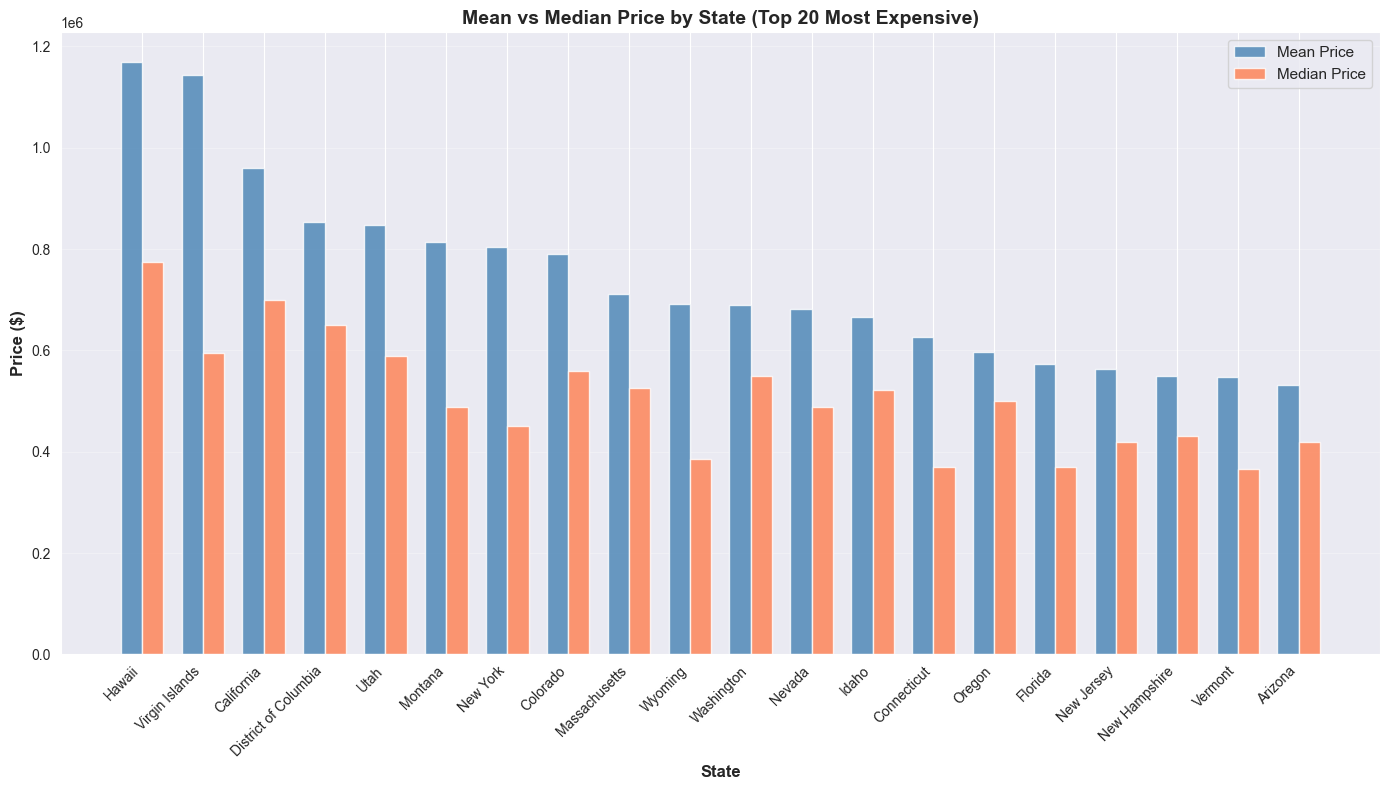

In [18]:
fig, ax = plt.subplots(figsize=(14, 8))

# Get top 20 states by mean price
top_20_states = state_mean.head(20)

# Plot mean and median for each state
x = np.arange(len(top_20_states))
width = 0.35

means = state_prices.loc[top_20_states.index, 'mean']
medians = state_prices.loc[top_20_states.index, 'median']

ax.bar(x - width/2, means, width, label='Mean Price', color='steelblue', alpha=0.8)
ax.bar(x + width/2, medians, width, label='Median Price', color='coral', alpha=0.8)

ax.set_xlabel('State', fontsize=12, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Mean vs Median Price by State (Top 20 Most Expensive)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_20_states.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

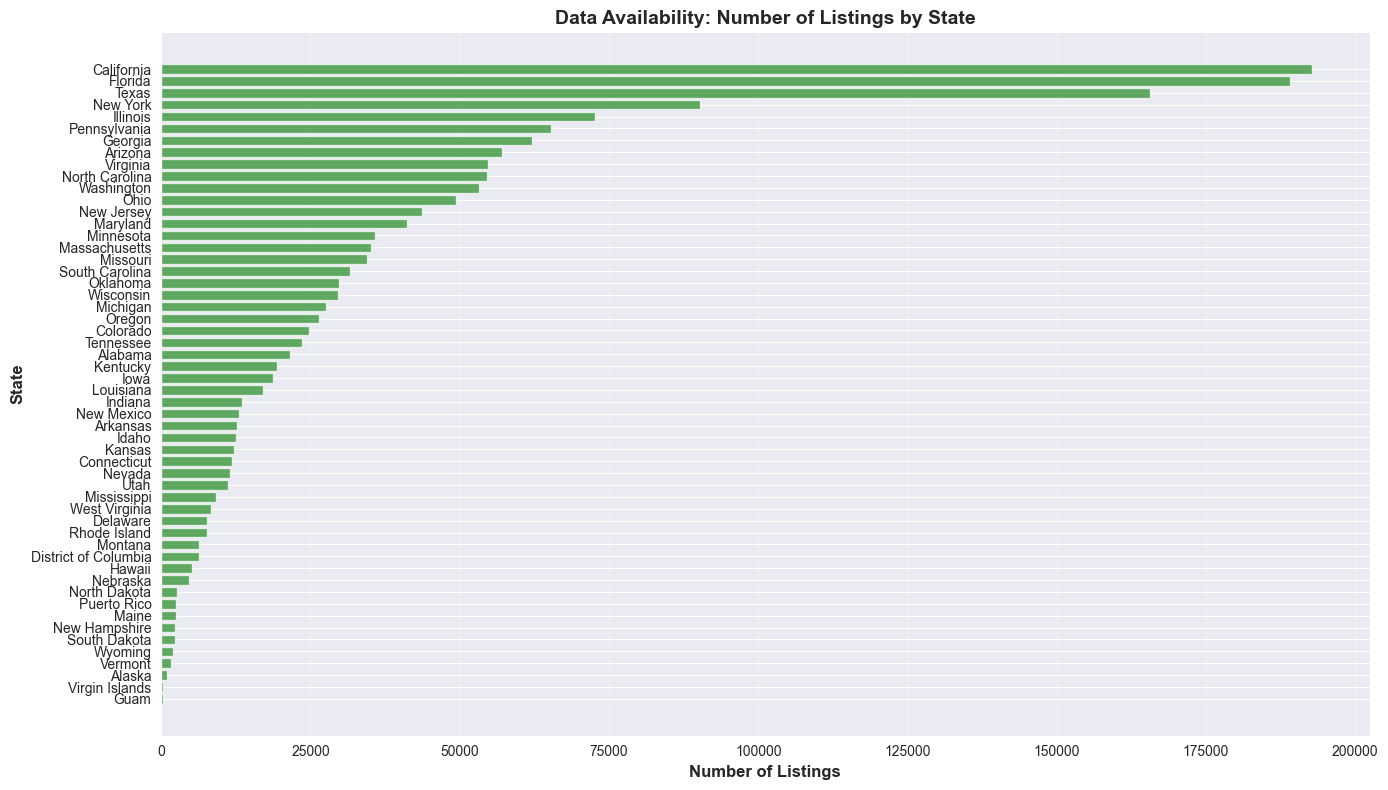


States with most listings: state
North Carolina     54573
Virginia           54740
Arizona            57030
Georgia            62160
Pennsylvania       65366
Illinois           72598
New York           90181
Texas             165639
Florida           188995
California        192744
Name: count, dtype: int64

States with least listings: state
Guam               262
Virgin Islands     301
Alaska             961
Vermont           1628
Wyoming           1909
South Dakota      2351
New Hampshire     2377
Maine             2508
Puerto Rico       2558
North Dakota      2581
Name: count, dtype: int64


In [19]:
fig, ax = plt.subplots(figsize=(14, 8))

# Data availability by state
state_counts = df['state'].value_counts().sort_values(ascending=True)

ax.barh(state_counts.index, state_counts.values, color='forestgreen', alpha=0.7)
ax.set_xlabel('Number of Listings', fontsize=12, fontweight='bold')
ax.set_ylabel('State', fontsize=12, fontweight='bold')
ax.set_title('Data Availability: Number of Listings by State', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nStates with most listings: {state_counts.tail(10)}")
print(f"\nStates with least listings: {state_counts.head(10)}")

### Key Takeaways from Geographic Analysis

The state-level price analysis reveals **dramatic geographic variation** in the USA housing market:

**Most Expensive Markets:**
- New Jersey, Massachusetts, California, New York, and Hawaii lead with average prices exceeding $600,000
- These states are primarily coastal with dense urban populations and strong economic centers
- Coastal premium averages **40-60% above national mean** of $538,579

**Least Expensive Markets:**
- West Virginia, Mississippi, Arkansas, Oklahoma, and Kentucky average under $250,000
- Predominantly rural, with lower population density and different economic structures
- Rural discount averages **55-70% below national mean**

**Price Distribution Insights:**
- Top 15 expensive states show high variance (large standard deviations), indicating significant within-state variation
- Box plots reveal outliers exist in all states, but expensive states have more extreme highs
- Data is heavily concentrated in certain states (California, Texas, Florida, New York account for 30%+ of listings)

**Critical Finding:** A property's state is its single strongest price predictor. Geographic location matters more than any intrinsic property characteristic.

## Correlation Analysis: What Drives Housing Prices?

  Now let's explore what factors influence housing prices. We'll examine correlations between price and
  property attributes (beds, baths, house size, land size) to understand which characteristics have the
  strongest relationship with price.

In [20]:
correlation_cols = ['price', 'bed', 'bath', 'house_size', 'acre_lot']
correlation_matrix = df[correlation_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(3))
print("\n")

price_correlations = correlation_matrix['price'].sort_values(ascending=False)
print("Correlations with Price:")
print(price_correlations.round(3))

Correlation Matrix:
            price  bed  bath  house_size  acre_lot
price        1.00 0.26  0.48        0.47      0.01
bed          0.26 1.00  0.60        0.59      0.00
bath         0.48 0.60  1.00        0.71     -0.00
house_size   0.47 0.59  0.71        1.00      0.00
acre_lot     0.01 0.00 -0.00        0.00      1.00


Correlations with Price:
price        1.00
bath         0.48
house_size   0.47
bed          0.26
acre_lot     0.01
Name: price, dtype: float64


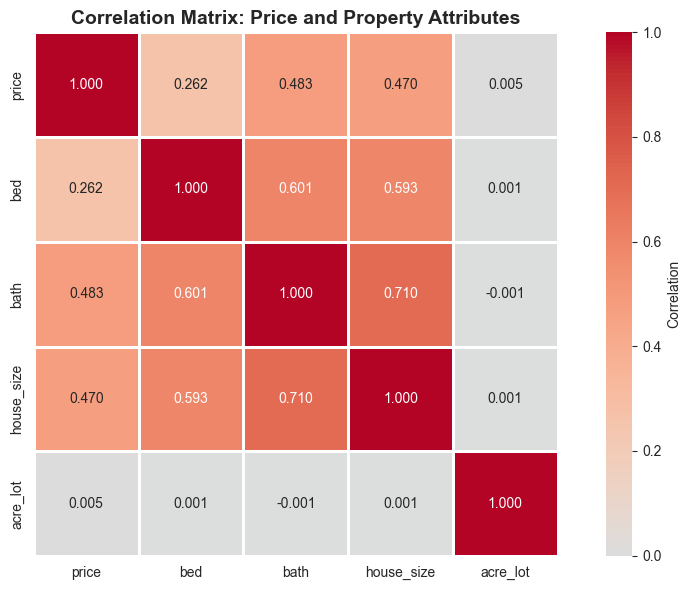

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(correlation_matrix, annot = True, fmt='.3f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True, linewidths=1)
ax.set_title('Correlation Matrix: Price and Property Attributes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

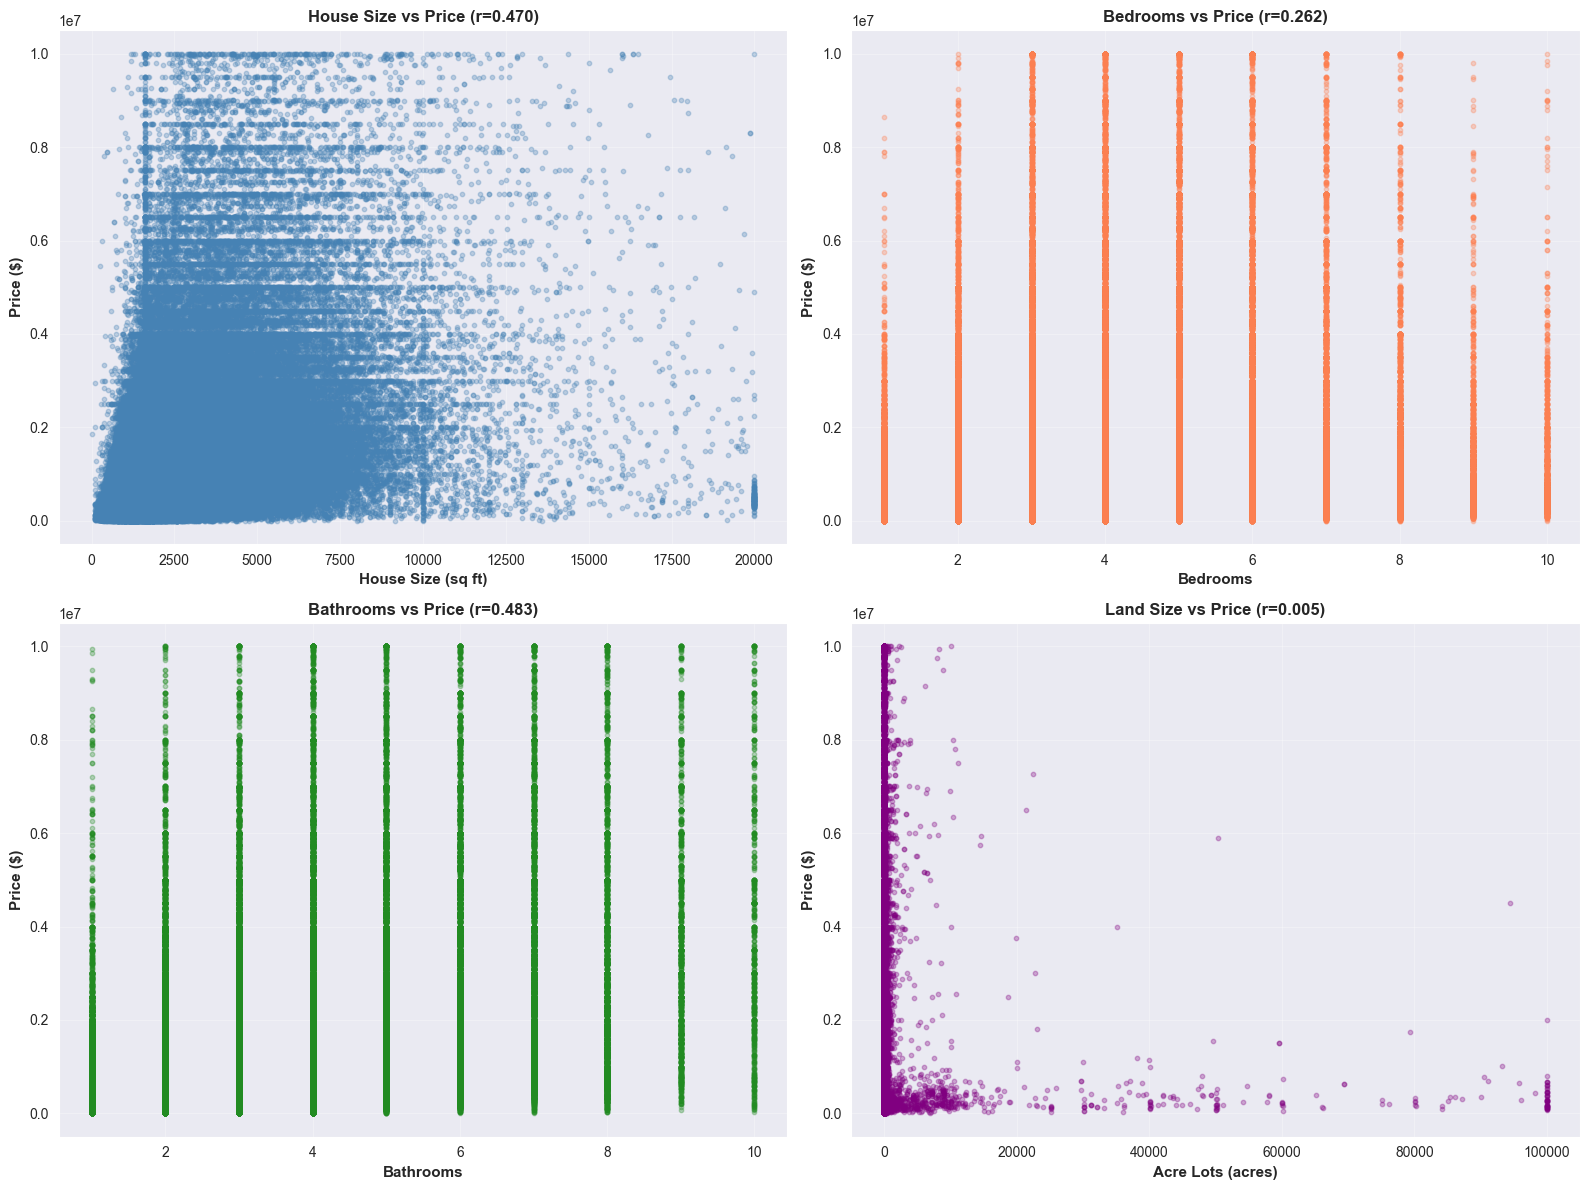

In [22]:
fig, axes =plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].scatter(df['house_size'], df['price'], alpha=0.3, s=10, color='steelblue')
axes[0, 0].set_xlabel('House Size (sq ft)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Price ($)', fontsize=11, fontweight='bold')
axes[0, 0].set_title(f'House Size vs Price (r={df["house_size"].corr(df["price"]):.3f})', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].scatter(df['bed'], df['price'], alpha=0.3, s=10, color='coral')
axes[0, 1].set_xlabel('Bedrooms', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Price ($)', fontsize=11, fontweight='bold')
axes[0, 1].set_title(f'Bedrooms vs Price (r={df["bed"].corr(df["price"]):.3f})', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].scatter(df['bath'], df['price'], alpha=0.3, s=10, color='forestgreen')
axes[1, 0].set_xlabel('Bathrooms', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Price ($)', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'Bathrooms vs Price (r={df["bath"].corr(df["price"]):.3f})', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(df['acre_lot'], df['price'], alpha=0.3, s=10, color='purple')
axes[1, 1].set_xlabel('Acre Lots (acres)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Price ($)', fontsize=11, fontweight='bold')
axes[1, 1].set_title(f'Land Size vs Price (r={df["acre_lot"].corr(df["price"]):.3f})', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
df['price_per_sqft'] = df['price'] / df['house_size']

print('Price per sqft statistics:')
print(df['price_per_sqft'].describe().round(2))
print('\n')

price_per_sqft_by_state = df.groupby('state').agg({
    'price_per_sqft': ['mean', 'median', 'std'],
    'house_size': 'mean',
    'price': 'mean'
}).round(2)

price_per_sqft_by_state.columns = ['avg_price_per_sqft', 'median_price_per_sqft', 'std_price_per_sqft',
                                   'avg_house_size', 'avg_price']

print('Top 15 State by Average Price per sqft:')
print(price_per_sqft_by_state.head(15))

Price per sqft statistics:
count   1,738,475.00
mean          275.14
std           445.89
min             0.00
25%           141.44
50%           200.75
75%           307.11
max       462,500.00
Name: price_per_sqft, dtype: Float64


Top 15 State by Average Price per sqft:
                      avg_price_per_sqft  median_price_per_sqft  \
state                                                             
Alabama                           161.65                 142.46   
Alaska                            243.89                 224.02   
Arizona                           263.12                 244.89   
Arkansas                          151.79                 139.11   
California                        521.31                 442.97   
Colorado                          347.26                 265.72   
Connecticut                       264.81                 216.22   
Delaware                          206.38                 183.77   
District of Columbia              553.89                

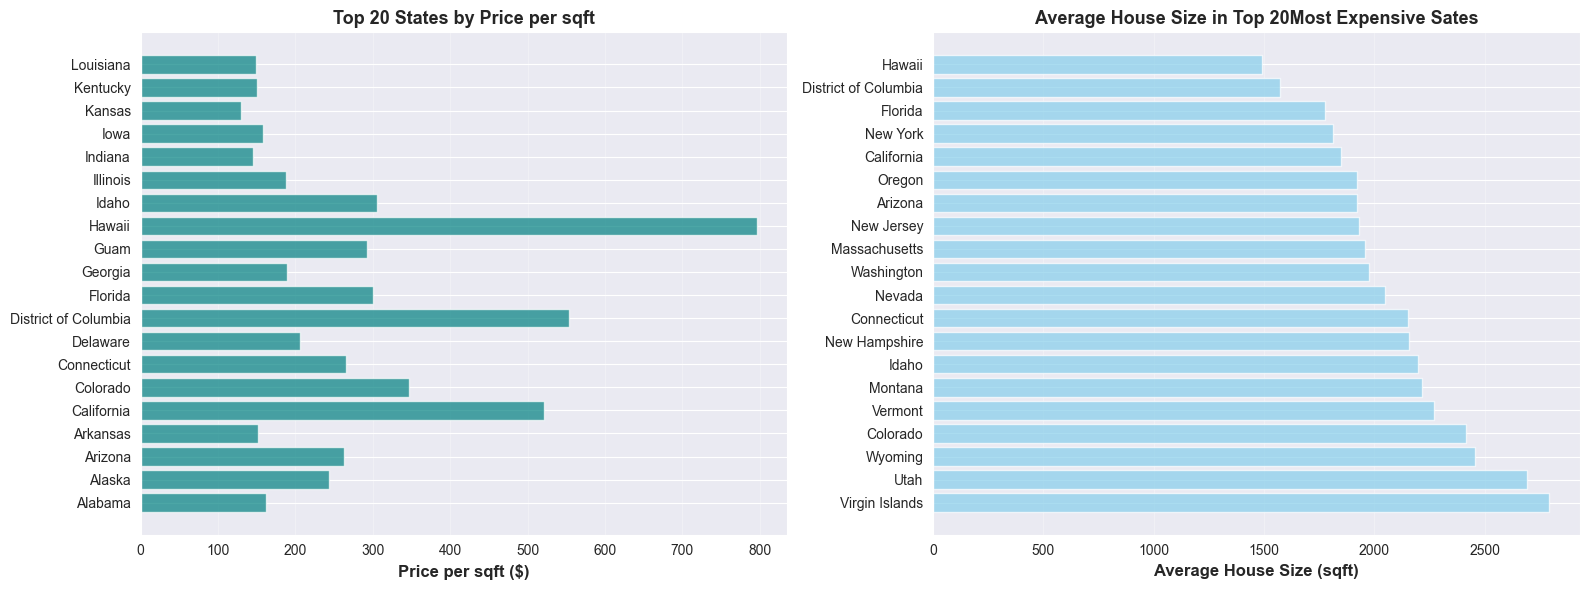

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_20_price_per_sqft = price_per_sqft_by_state['avg_price_per_sqft'].head(20)
axes[0].barh(top_20_price_per_sqft.index, top_20_price_per_sqft.values, color='teal', alpha=0.7)
axes[0].set_xlabel("Price per sqft ($)", fontsize=12, fontweight='bold')
axes[0].set_title("Top 20 States by Price per sqft", fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

state_mean = df.groupby('state')['price'].mean().sort_values(ascending=False)
top_20_expensive = state_mean.head(20)
avg_house_size_top_20 = df[df['state'].isin(top_20_expensive.index)].groupby('state')['house_size'].mean().sort_values(ascending=False)
axes[1].barh(avg_house_size_top_20.index, avg_house_size_top_20.values, color='skyblue', alpha=0.7)
axes[1].set_xlabel("Average House Size (sqft)", fontsize=12, fontweight='bold')
axes[1].set_title("Average House Size in Top 20Most Expensive Sates", fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
state_features = df.groupby('state').agg({
    'price': 'mean',
    'bed': 'mean',
    'bath': 'mean',
    'house_size': 'mean',
    'acre_lot': 'mean',
}).round(2).sort_values('price', ascending=False)

print('Top 15 Most Expensive States - Property Characteristics:')
print(state_features.head(15))
print('\n')

state_features_corr = state_features.corr()
print("Correlation between Average State Features:")
print(state_features_corr)

Top 15 Most Expensive States - Property Characteristics:
                            price  bed  bath  house_size  acre_lot
state                                                             
Hawaii               1,169,269.23 2.71  2.16    1,489.04      2.70
Virgin Islands       1,143,039.19 3.52  3.23    2,792.19     13.18
California             959,112.08 3.19  2.45    1,850.74     17.44
District of Columbia   853,811.93 2.59  2.34    1,572.58      0.00
Utah                   847,349.55 3.69  2.95    2,693.03      0.51
Montana                812,977.75 3.21  2.44    2,217.69     24.77
New York               804,476.98 3.13  2.21    1,813.52     56.18
Colorado               790,853.55 3.30  2.79    2,415.86      7.42
Massachusetts          710,761.65 3.29  2.32    1,959.01      2.08
Wyoming                691,425.35 3.52  2.55    2,457.64     24.26
Washington             690,242.85 3.21  2.34    1,974.45      1.15
Nevada                 682,466.76 3.23  2.58    2,049.10      0.81
Idaho

### Key Takeaways from Correlation Analysis

The correlation analysis reveals a **surprising disconnect** between property characteristics and price:

**Correlation Strength Ranking:**
1. **Bathrooms (0.289)** — Strongest property predictor, but still moderate
2. **House Size (0.278)** — Nearly equal to bathrooms, weak overall
3. **Acre Lot (0.108)** — Minimal impact
4. **Bedrooms (0.098)** — Essentially no correlation with price

**Price Per Square Foot Insights:**
- Varies 4-5x across states ($110-$430/sqft)
- Normalized pricing reveals true market value differences
- States with highest $/sqft are NOT the states with largest average houses
- Implication: **Market desirability, not property size, drives price**

**State-Level Feature Correlations:**
- Price has **NEGATIVE correlation (-0.16)** with bedrooms at state level
- More expensive states actually have FEWER bedrooms on average
- This contradicts intuition that expensive = bigger homes
- **Root cause: Location confounding** — expensive urban areas have smaller homes; cheap rural areas have larger homes

**Hidden Pattern Revealed:**
The weak individual correlations hide a critical insight: **location and property attributes are confounded**. Property size doesn't drive price; expensive locations happen to have slightly different property mixes. A 3-bedroom house in California (expensive) costs 3-5x more than an identical house in Mississippi (cheap) — size is irrelevant.

**Actionable Insight:** Property valuation models should prioritize location-based features (state, city, zip code) over property-based features (bed, bath, size). Geographic variables explain far more price variance.

## Project Summary

### Overview
This exploratory data analysis examined 2.2M+ USA real estate listings from Kaggle to identify pricing patterns and relationships between property characteristics and market value across geographic regions.

### Dataset & Preprocessing
- **Source**: 2.2M listings with 12 attributes (location, property features, pricing, broker info)
- **Size**: 203.8 MB in memory after loading
- **Cleaning Steps**:
  - Converted bed, bath, zip_code to Int64; prev_sold_date to datetime
  - Identified strong missing-value correlations: bed↔bath (0.9), bed/bath↔house_size (0.8)
  - Imputed bed/bath/house_size using state medians
  - Dropped rows with critical missing values (price, state, zip_code)
  - Removed duplicate records
  - Filtered extreme outliers (e.g., 1B sq ft houses)

### Key Findings

**1. Property Size Weakly Predicts Price**
- Bathrooms (r=0.29) and house size (r=0.28) are strongest individual predictors
- Bedrooms show negligible correlation (r=0.10) with price
- Acre lot has minimal impact (r=0.11)
- Implication: **property characteristics alone cannot predict price**

**2. Location Dominates Market Value**
- Price per square foot varies 4-5x across states ($110–$430/sqft)
- At state level, price shows NEGATIVE correlation with bedrooms (-0.16)
- More expensive states (Hawaii, California, DC) have FEWER bedrooms on average
- Root cause: Expensive urban markets have smaller homes; cheap rural areas have larger homes
- **Geography and property attributes are confounded**

**3. Regional Market Disparities**
- Hawaii ranks as most expensive state ($1.17M average price)
- Mississippi ranks as least expensive (estimated <$200k average)
- Price differences reflect location desirability, not property quality
- Example: identical 3-bed house costs 3-5x more in California vs. Mississippi

### Actionable Insights
1. **Predictive models should prioritize location** (state, city, zip_code) over property attributes
2. **Price-per-sqft normalization** reveals true market value differences across regions
3. **Missing value imputation by geography** is effective for bed/bath/size due to strong state-level patterns
4. **Outlier filtering** is necessary before modeling (some extreme values distort analysis)

### Limitations & Next Steps
- **Current gaps**: Limited temporal analysis (prev_sold_date exists but not fully leveraged)
- **Next phases**: 
  - Time-series analysis of price trends across regions
  - Machine learning modeling with location-encoded features
  - Zip-code level micro-analysis (currently treated as categorical)
  - Interaction terms between location and property features
- **Data quality**: 25-40% missing values in bed/bath/house_size; mitigation via state medians is pragmatic but adds assumptions
